# Расчет и визуализация Гомановского перехода

In [2]:
R=6371 # Радиус Земли
fM=398.6*10**3 #гравитационный параметр Земли

h_p0=8000 #высоты начальной орбиты
h_a0=8500
h_pk=2000 #высоты конечной орбиты
h_ak=11000

r_p0=R+h_p0 #радиус-векторы
r_a0=R+h_a0
r_pk=R+h_pk
r_ak=R+h_ak



In [3]:
from math import sqrt

## Двухимпульсный перелёт из перигея начальной орбиты в апогей конечной орбиты

In [4]:
def V(r1,r2):
    V=sqrt(2*fM/r1-2*fM/(r1+r2))
    return V

V0=V(r_p0,r_a0)
V1=V(r_p0,r_ak)
V11=V(r_ak,r_p0)
Vk=V(r_ak,r_pk)

dV1=V1-V0
dV2=Vk-V11
dV_sum=abs(dV1)+abs(dV2)

print('Суммарный импульс',f"{dV_sum:.3f}",'км/с')

Суммарный импульс 0.894 км/с


In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def ellipse_coords (rp, ra, u_max, num_points=100):
    a = (rp + ra) / 2          # большая полуось
    e = (ra - rp) / (ra + rp)  # эксцентриситет
    u = np.linspace(0, u_max, num_points) #истинная аномалия
    r = a *(1 - e**2) / (1 + e*np.cos(u)) #уравнение орбиты
    x = r * np.cos(u) # переход из полярных координат в декартовы
    y = r * np.sin(u)
    return x, y

In [7]:
x0, y0 = ellipse_coords(r_p0, r_a0, 2*np.pi) # массивы координат точек - исходная орбита
x1, y1 = ellipse_coords(r_p0, r_ak, np.pi) # переходная
xk, yk = ellipse_coords(r_pk, r_ak, 2*np.pi) # конечная

In [8]:
plt.figure(figsize=(12,10)) #создание графика

<Figure size 864x720 with 0 Axes>

<Figure size 864x720 with 0 Axes>

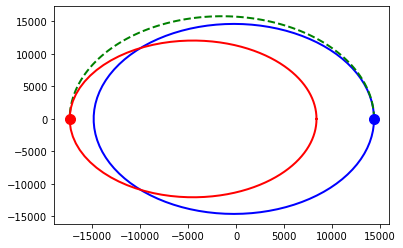

In [9]:
plt.plot(x0, y0, 'b-', linewidth=2, label=f'Исходная орбита ($r_p={r_p0}$ км, $r_a={r_a0}$ км)')
plt.plot(x1, y1, 'g--', linewidth=2, label=f'Промежуточная ($r_a={r_ak}$ км)')
plt.plot(xk, yk, 'r-', linewidth=2, label=f'Конечная ($r_p={r_pk}$ км)')

# Отметки точек манёвров (в перигее и апогее)
plt.scatter([r_p0], [0], s=100, c='blue', zorder=5, label='Маневр 1 (перигей начальной)')
plt.scatter([-r_ak], [0], s=100, c='red', zorder=5, label='Манёвр 2 (апогей конечной)')

In [10]:
plt.savefig('plot.png')

<Figure size 432x288 with 0 Axes>